In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
plt.style.use("seaborn-v0_8")

In [3]:
prices_raw_2 = pd.read_csv("prices_round_5_day_2.csv", sep = ";", index_col = "timestamp")
prices_raw_3 = pd.read_csv("prices_round_5_day_3.csv", sep = ";", index_col = "timestamp")
prices_raw_4 = pd.read_csv("prices_round_5_day_4.csv", sep = ";", index_col = "timestamp")
prices_raw_3.index = prices_raw_3.index + prices_raw_2.index.max() + 100
prices_raw_4.index = prices_raw_4.index + prices_raw_3.index.max() + 100
prices_raw = pd.concat([prices_raw_2, prices_raw_3, prices_raw_4], axis=0)
mid_prices = prices_raw[["product", "mid_price"]]
mid_prices = (
    mid_prices.reset_index()  # makes timestamp a normal column (usually named "timestamp")
       .pivot(index="timestamp", columns="product", values="mid_price")
       .sort_index()
)

In [56]:
sector = mid_prices.filter(regex=r'^MICROCHIP').copy()
log_prices = np.log(sector.loc[2000000:])
a = log_prices.iloc[:, 0]
b = log_prices.iloc[:, 1]
c = log_prices.iloc[:, 2]
d = log_prices.iloc[:, 3]
e = log_prices.iloc[:, 4]
y3 = np.column_stack([b, c, e])
log_prices

product,MICROCHIP_CIRCLE,MICROCHIP_OVAL,MICROCHIP_RECTANGLE,MICROCHIP_SQUARE,MICROCHIP_TRIANGLE
timestamp,,,,,
2000000,9.051931,8.911463,8.965782,9.674766,9.107200
2000100,9.050993,8.913887,8.965015,9.672753,9.106257
2000200,9.050524,8.915029,8.965271,9.672375,9.106867
2000300,9.052282,8.915231,8.966037,9.672501,9.103868
2000400,9.053219,8.917378,8.966292,9.671682,9.104091
...,...,...,...,...,...
2999500,9.243630,8.611048,9.084210,9.521055,8.979732
2999600,9.243146,8.611321,9.081256,9.521128,8.981430
2999700,9.245804,8.613230,9.079434,9.519368,8.978850


In [57]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

result = coint_johansen(y3, 0, 1)
print("Trace Statistic: \n", result.lr1)
print("Trace Critical Values: \n", result.cvt)
print("Max Eigenvalue Statistic: \n", result.lr2)
print("Max Eigenvalue Critical Values: \n", result.cvm)

Trace Statistic: 
 [33.86761997  6.27166434  2.2316831 ]
Trace Critical Values: 
 [[27.0669 29.7961 35.4628]
 [13.4294 15.4943 19.9349]
 [ 2.7055  3.8415  6.6349]]
Max Eigenvalue Statistic: 
 [27.59595563  4.03998124  2.2316831 ]
Max Eigenvalue Critical Values: 
 [[18.8928 21.1314 25.865 ]
 [12.2971 14.2639 18.52  ]
 [ 2.7055  3.8415  6.6349]]


In [58]:
beta = result.evec[:, 0]
beta

array([ 27.05870098,  -5.67956411, -53.13226851])

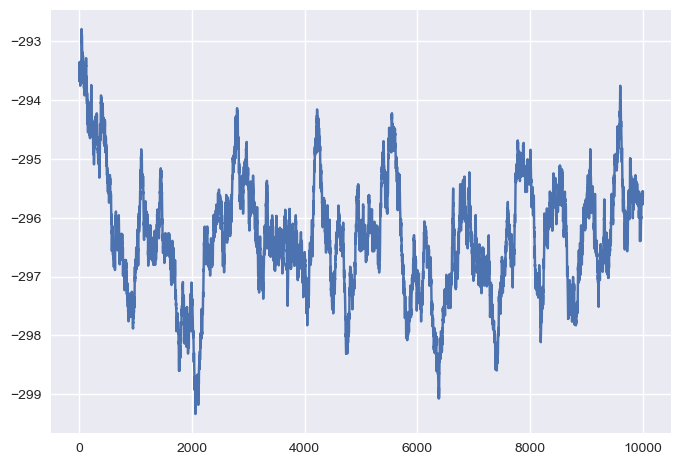

In [59]:
spread = y3 @ beta
plt.plot(spread)

In [60]:
import statsmodels.tsa.stattools as ts
cadf = ts.adfuller(spread)
print ('Augmented Dickey Fuller test statistic =',cadf[0])
print ('Augmented Dickey Fuller p-value =',cadf[1])
print ('Augmented Dickey Fuller 1%, 5% and 10% test statistics =',cadf[4])

Augmented Dickey Fuller test statistic = -4.821892234202517
Augmented Dickey Fuller p-value = 4.9377179295456e-05
Augmented Dickey Fuller 1%, 5% and 10% test statistics = {'1%': np.float64(-3.4310041633725734), '5%': np.float64(-2.861829101294412), '10%': np.float64(-2.566923883481157)}


In [61]:
spread.mean()

np.float64(-296.3239898061306)

In [62]:
spread.std()

np.float64(1.0013297704389608)

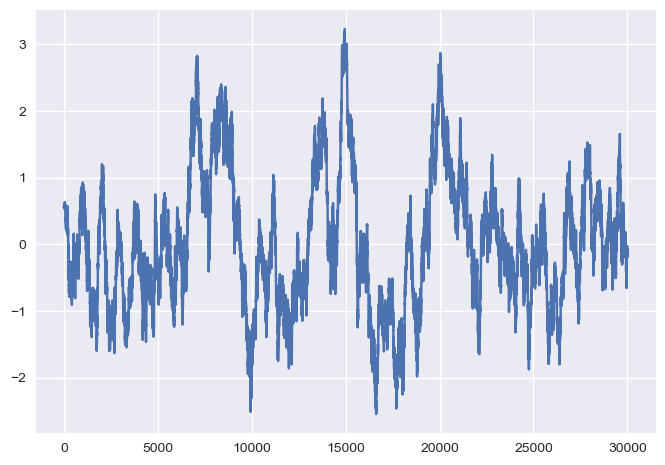

In [52]:
z_spread = (spread - spread.mean()) / spread.std()
plt.plot(z_spread)